# **Importing Libs**

In [16]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

# img path


In [17]:
path  = r"M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Test\Testing_Our_Dataset\bike2.jpg"

# labels

In [18]:
label_dict = { "airplane": 0, "car": 1, "motorbike": 2}

# Function

In [19]:
def preprocess_image(image_path, size, Colored=True, for_ann=False):
    try:
        if Colored:
            dimensions = 3
            img = cv2.imread(image_path)
        else:
            dimensions = 1
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            
        if img is None:
            raise ValueError(f"Failed to load image from {image_path}")
            
        img = cv2.resize(img, (size, size))
        img = img / 255.0  

        if for_ann:
            # Flatten for ANN
            img = img.reshape(1, size * size * dimensions)
        else:
            # Keep 3D shape for CNNs or LeNet 
            img = img.reshape(1, size, size, dimensions)
            
        return img

    except Exception as e:
        print(f"Error preprocessing image: {str(e)}")
        return None


In [20]:
def make_prediction(model, img, model_name):
    try:
        prediction = model.predict(img)  # Reduce verbosity
        predicted_class = np.argmax(prediction)
        confidence_scores = prediction[0]
        
        # Get top 3 predictions
        top_3_idx = np.argsort(confidence_scores)[-3:][::-1]
        
        print(f"\n{model_name} Predictions:")
        print("-" * 40)
        for idx in top_3_idx:
            class_name = [k for k, v in label_dict.items() if v == idx][0]
            print(f"{class_name}: {confidence_scores[idx]:.2%}")
        print("-" * 40)
        
        return predicted_class, confidence_scores
    except Exception as e:
        print(f"Error making prediction: {str(e)}")
        return None, None

# **Load_ANN MODEL**

In [21]:
Ann_model = tf.keras.models.load_model(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\ANN_model.keras')

# Predictions

In [22]:
img = preprocess_image(path, 110, Colored=True, for_ann=True)
if img is not None:
    make_prediction(Ann_model, img, "ANN Model")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

ANN Model Predictions:
----------------------------------------
airplane: 51.29%
car: 45.33%
motorbike: 3.38%
----------------------------------------


# **Load_CNN MODEL**

In [23]:
CNN_model = tf.keras.models.load_model(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\CNN_MAX_model.keras')

# Predictions

In [24]:
img = preprocess_image(path, 110, Colored=True, for_ann=False)
make_prediction(CNN_model, img, "CNN Model")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

CNN Model Predictions:
----------------------------------------
motorbike: 100.00%
airplane: 0.00%
car: 0.00%
----------------------------------------


(2, array([2.2848567e-08, 7.4607520e-09, 1.0000000e+00], dtype=float32))

# **Load_Lenet MODEL**

In [25]:
LeNet_model = tf.keras.models.load_model(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\lenet_model.keras')

# Predictions

In [26]:
img = preprocess_image(path, 32, Colored=False, for_ann=False)
make_prediction(LeNet_model, img, "LeNet Model")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

LeNet Model Predictions:
----------------------------------------
motorbike: 57.53%
car: 23.49%
airplane: 18.98%
----------------------------------------


(2, array([0.18983623, 0.2348801 , 0.57528377], dtype=float32))

# **Load Resent Model**

In [27]:
Resnet_model = tf.keras.models.load_model(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\Resnet50_224_model.keras')

# Predictions


In [28]:
img = preprocess_image(path, 224, Colored=True, for_ann=False)
make_prediction(Resnet_model, img, "Resnet Model")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Resnet Model Predictions:
----------------------------------------
motorbike: 100.00%
car: 0.00%
airplane: 0.00%
----------------------------------------


(2, array([1.9055183e-07, 3.7804108e-07, 9.9999940e-01], dtype=float32))

# **Load AutoEncoder Model**

In [29]:
Autoencoder_model = tf.keras.models.load_model(r'M:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\autoencoder_final.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

Autoencoder Reconstruction Complete.


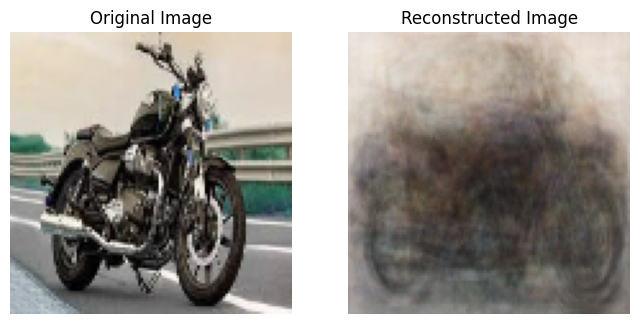

In [30]:
# preprocess image for autoencoder
img = preprocess_image(path, 110, Colored=True, for_ann=True)
reconstructed_img = Autoencoder_model.predict(img)
print("\nAutoencoder Reconstruction Complete.")





# Visualize original and reconstructed images
reconstructed_img_reshaped = reconstructed_img.reshape(110, 110, 3)
original_img_reshaped = img.reshape(110, 110, 3)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_img_reshaped)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title("Reconstructed Image")
plt.imshow(reconstructed_img_reshaped)
plt.axis('off')
plt.show()

